# UAVDT Notebook 03A — Use Ground-Truth Annotations Instead of YOLO

This notebook is an alternative to Notebook #3. It uses `M1401_gt_whole.txt` annotations from the UAVDT MOT/DET toolkit instead of YOLO detections and nearest-neighbor tracking.

Goal:

1. Load sampled frames from Drive.
2. Load the homography from Notebook #2.
3. Load `GT/M1401_gt_whole.txt`.
4. Map sampled frames to original UAVDT frame indices.
5. Use `target_id` as the stable `track_id`.
6. Project annotation boxes to BEV.
7. Save BEV tracks for Notebook #4/#5/#6.
8. Render validation overlays and a short side-by-side video.


In [1]:
#@title 1. Set local project paths and imports
from pathlib import Path
import json
import math
import shutil

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from notebook_local import resolve_project_dir, print_local_setup

PROJECT_DIR = resolve_project_dir()
WORK_DIR = PROJECT_DIR / 'work'
SAMPLE_DIR = WORK_DIR / 'M1401_sample'
SAMPLE_IMAGES_DIR = SAMPLE_DIR / 'images'
NB02_DIR = WORK_DIR / 'notebook_02_bev_homography'
NB03A_DIR = WORK_DIR / 'notebook_03a_gt_annotations_bev_tracks'
NB03A_DIR.mkdir(parents=True, exist_ok=True)

print_local_setup(PROJECT_DIR)
print('SAMPLE_IMAGES_DIR:', SAMPLE_IMAGES_DIR)
print('NB02_DIR:', NB02_DIR)
print('NB03A_DIR:', NB03A_DIR)
print('Sample images dir exists:', SAMPLE_IMAGES_DIR.exists())


PROJECT_DIR: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project
DATASET_DIR: not found
Set DRONE3D_PROJECT_DIR and UAVDT_DATASET_DIR to override these defaults.
SAMPLE_IMAGES_DIR: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/M1401_sample/images
NB02_DIR: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_02_bev_homography
NB03A_DIR: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_03a_gt_annotations_bev_tracks
Sample images dir exists: True


In [2]:
#@title 2. Configuration

from notebook_local import default_gt_path, find_sequence_dir

# Path to the annotation file on your local machine.
GT_WHOLE_PATH = default_gt_path('M1401_gt_whole.txt', PROJECT_DIR) #@param {type:'string'}
GT_WHOLE_PATH = Path(GT_WHOLE_PATH)

# Original raw frame folder. Used only for optional mapping checks.
RAW_M1401_DIR = find_sequence_dir('M1401', PROJECT_DIR) #@param {type:'string'}
RAW_M1401_DIR = Path(RAW_M1401_DIR)

# If Notebook #1 saved renamed frames frame_00000.jpg, frame_00001.jpg, ...
# then we need to know what original UAVDT frame each sample corresponds to.
# Example: if frame_00000.jpg is img001040.jpg, set START_FRAME_INDEX = 1040.
# If frame_00000.jpg is img000001.jpg, set START_FRAME_INDEX = 1.
START_FRAME_INDEX = 1 #@param {type:'integer'}
FRAME_STEP = 10 #@param {type:'integer'}
MAX_FRAMES = 50 #@param {type:'integer'}

# If a sample frame mapping CSV exists, the notebook will use it automatically.
# Otherwise it uses START_FRAME_INDEX and FRAME_STEP.
FRAME_MAPPING_CSV = SAMPLE_DIR / 'frame_mapping.csv'

# Box ground point used for BEV projection.
# bottom_center: typical for boxes on road plane.
# lower_center_25: a point slightly above the box bottom to reduce some annotation noise.
GROUND_POINT_MODE = 'bottom_center' #@param ['bottom_center', 'lower_center_25']

# UAVDT category IDs: 1=car, 2=truck, 3=bus. Empty list keeps all categories.
KEEP_CATEGORIES = [1, 2, 3] #@param

# Visibility filters are optional; disabled by default to preserve all GT rows.
APPLY_VISIBILITY_FILTERS = False #@param {type:'boolean'}
MAX_OCCLUSION = 2 #@param {type:'integer'}
MAX_OUT_OF_VIEW = 2 #@param {type:'integer'}

# Rendering controls for validation overlays and side-by-side video.
MAX_RENDER_FRAMES = 30 #@param {type:'integer'}
VIDEO_FPS = 8 #@param {type:'integer'}


In [3]:
#@title 3. Load sample frames and build original-frame mapping

sample_images = sorted(list(SAMPLE_IMAGES_DIR.glob('*.jpg')) + list(SAMPLE_IMAGES_DIR.glob('*.png')))
if MAX_FRAMES is not None and MAX_FRAMES > 0:
    sample_images = sample_images[:MAX_FRAMES]

if len(sample_images) == 0:
    raise FileNotFoundError('No sample images found in ' + str(SAMPLE_IMAGES_DIR))

print('Loaded sample images:', len(sample_images))
print('First sample image:', sample_images[0].name)
print('Last sample image:', sample_images[-1].name)

mapping = None

if FRAME_MAPPING_CSV.exists():
    mapping = pd.read_csv(FRAME_MAPPING_CSV)
    print('Loaded existing frame mapping CSV:', FRAME_MAPPING_CSV)
    print('Mapping columns:', mapping.columns.tolist())
else:
    sample_manifest_path = SAMPLE_DIR / 'sample_manifest.json'
    if sample_manifest_path.exists():
        print('No frame_mapping.csv found. Building mapping from sample manifest:', sample_manifest_path)
        manifest = json.loads(sample_manifest_path.read_text())
        rows = []
        for fallback_idx, item in enumerate(manifest):
            sample_path = Path(item.get('sample_path', ''))
            source_path = Path(item.get('source_path', ''))
            source_stem_digits = ''.join(ch for ch in source_path.stem if ch.isdigit())
            if not source_stem_digits:
                raise ValueError('Cannot parse original frame index from source_path: ' + str(source_path))
            sample_idx = int(item.get('sample_index', fallback_idx))
            original_frame_index = int(source_stem_digits)
            rows.append({
                'sample_frame_idx': sample_idx,
                'sample_name': sample_path.name,
                'sample_path': str(sample_path),
                'original_frame_index': original_frame_index,
                'original_name': source_path.name,
                'original_path': str(source_path),
            })
        mapping = pd.DataFrame(rows)
    else:
        print('No frame_mapping.csv or sample_manifest.json found. Building mapping from START_FRAME_INDEX and FRAME_STEP.')
        rows = []
        for sample_idx, p in enumerate(sample_images):
            original_frame_index = START_FRAME_INDEX + sample_idx * FRAME_STEP
            original_name = 'img' + str(original_frame_index).zfill(6) + '.jpg'
            rows.append({
                'sample_frame_idx': sample_idx,
                'sample_name': p.name,
                'sample_path': str(p),
                'original_frame_index': original_frame_index,
                'original_name': original_name,
                'original_path': str(RAW_M1401_DIR / original_name),
            })
        mapping = pd.DataFrame(rows)

# Normalize likely mapping columns.
if 'sample_frame_idx' not in mapping.columns:
    if 'frame_id' in mapping.columns:
        mapping['sample_frame_idx'] = mapping['frame_id']
    elif 'sample_index' in mapping.columns:
        mapping['sample_frame_idx'] = mapping['sample_index']
    else:
        mapping['sample_frame_idx'] = range(len(mapping))

if 'sample_name' not in mapping.columns:
    if 'sample_image' in mapping.columns:
        mapping['sample_name'] = mapping['sample_image']
    else:
        mapping['sample_name'] = [p.name for p in sample_images[:len(mapping)]]

if 'original_frame_index' not in mapping.columns:
    if 'frame_index' in mapping.columns:
        mapping['original_frame_index'] = mapping['frame_index']
    elif 'original_index' in mapping.columns:
        mapping['original_frame_index'] = mapping['original_index']
    else:
        mapping['original_frame_index'] = START_FRAME_INDEX + mapping['sample_frame_idx'].astype(int) * FRAME_STEP

mapping = mapping.copy()
mapping['sample_frame_idx'] = mapping['sample_frame_idx'].astype(int)
mapping['original_frame_index'] = mapping['original_frame_index'].astype(int)

# Keep rows corresponding to existing sample images.
valid_names = set([p.name for p in sample_images])
mapping = mapping[mapping['sample_name'].isin(valid_names)].copy()
if len(mapping) == 0:
    raise RuntimeError('Frame mapping has no rows matching sample image names.')

mapping_path = NB03A_DIR / 'frame_mapping_used.csv'
mapping.to_csv(mapping_path, index=False)

print('Saved mapping used:', mapping_path)
print('Mapping rows:', len(mapping))
display(mapping.head(10))


Loaded sample images: 40
First sample image: frame_00000.jpg
Last sample image: frame_00039.jpg
No frame_mapping.csv found. Building mapping from sample manifest: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/M1401_sample/sample_manifest.json
Saved mapping used: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_03a_gt_annotations_bev_tracks/frame_mapping_used.csv
Mapping rows: 40


,sample_frame_idx,sample_name,sample_path,original_frame_index,original_name,original_path
0,0,frame_00000.jpg,/Users/vash/Dev/ResearchLab/Work/Drone3D/local...,1,img000001.jpg,/Users/vash/Dev/ResearchLab/DataSets/UAV/UAV-b...
1,1,frame_00001.jpg,/Users/vash/Dev/ResearchLab/Work/Drone3D/local...,6,img000006.jpg,/Users/vash/Dev/ResearchLab/DataSets/UAV/UAV-b...
2,2,frame_00002.jpg,/Users/vash/Dev/ResearchLab/Work/Drone3D/local...,11,img000011.jpg,/Users/vash/Dev/ResearchLab/DataSets/UAV/UAV-b...
3,3,frame_00003.jpg,/Users/vash/Dev/ResearchLab/Work/Drone3D/local...,16,img000016.jpg,/Users/vash/Dev/ResearchLab/DataSets/UAV/UAV-b...
4,4,frame_00004.jpg,/Users/vash/Dev/ResearchLab/Work/Drone3D/local...,21,img000021.jpg,/Users/vash/Dev/ResearchLab/DataSets/UAV/UAV-b...
5,5,frame_00005.jpg,/Users/vash/Dev/ResearchLab/Work/Drone3D/local...,26,img000026.jpg,/Users/vash/Dev/ResearchLab/DataSets/UAV/UAV-b...
6,6,frame_00006.jpg,/Users/vash/Dev/ResearchLab/Work/Drone3D/local...,31,img000031.jpg,/Users/vash/Dev/ResearchLab/DataSets/UAV/UAV-b...
7,7,frame_00007.jpg,/Users/vash/Dev/ResearchLab/Work/Drone3D/local...,36,img000036.jpg,/Users/vash/Dev/ResearchLab/DataSets/UAV/UAV-b...
8,8,frame_00008.jpg,/Users/vash/Dev/ResearchLab/Work/Drone3D/local...,41,img000041.jpg,/Users/vash/Dev/ResearchLab/DataSets/UAV/UAV-b...
9,9,frame_00009.jpg,/Users/vash/Dev/ResearchLab/Work/Drone3D/local...,46,img000046.jpg,/Users/vash/Dev/ResearchLab/DataSets/UAV/UAV-b...


In [4]:
#@title 4. Load homography from Notebook 02

candidate_paths = [
    NB02_DIR / 'homography.json',
    NB02_DIR / 'bev_homography.json',
]
candidate_paths += sorted(NB02_DIR.glob('*homography*.json'))

print('Homography candidates:')
for p in candidate_paths:
    print(str(p), 'exists:', p.exists())

homography_path = None
for p in candidate_paths:
    if p.exists():
        homography_path = p
        break

if homography_path is None:
    raise FileNotFoundError('Could not find homography JSON in ' + str(NB02_DIR))

print('Using homography:', homography_path)
with open(homography_path, 'r') as f:
    homography_data = json.load(f)

if 'H_image_to_bev' in homography_data:
    H_image_to_bev = np.array(homography_data['H_image_to_bev'], dtype=np.float32)
elif 'homography' in homography_data:
    H_image_to_bev = np.array(homography_data['homography'], dtype=np.float32)
elif 'H' in homography_data:
    H_image_to_bev = np.array(homography_data['H'], dtype=np.float32)
else:
    raise KeyError('Homography JSON must contain H_image_to_bev, homography, or H.')

BEV_WIDTH = int(homography_data.get('bev_width', homography_data.get('BEV_WIDTH', 600)))
BEV_HEIGHT = int(homography_data.get('bev_height', homography_data.get('BEV_HEIGHT', 1000)))

print('BEV_WIDTH:', BEV_WIDTH)
print('BEV_HEIGHT:', BEV_HEIGHT)
print('H_image_to_bev:')
print(H_image_to_bev)


Homography candidates:
/Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_02_bev_homography/homography.json exists: False
/Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_02_bev_homography/bev_homography.json exists: False
/Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_02_bev_homography/frame_00000_homography.json exists: True
Using homography: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_02_bev_homography/frame_00000_homography.json
BEV_WIDTH: 600
BEV_HEIGHT: 1000
H_image_to_bev:
[[ 2.1048594e+00  1.1751100e+00 -1.0527084e+03]
 [ 7.5697026e-16  5.8061533e+00 -6.2706458e+02]
 [ 7.4099501e-19  2.7350422e-03  1.0000000e+00]]


In [5]:
#@title 5. Load UAVDT gt_whole annotations

if not GT_WHOLE_PATH.exists():
    raise FileNotFoundError('Annotation file not found: ' + str(GT_WHOLE_PATH))

cols = [
    'frame_index',
    'target_id',
    'bbox_left',
    'bbox_top',
    'bbox_width',
    'bbox_height',
    'out_of_view',
    'occlusion',
    'object_category',
]

ann = pd.read_csv(GT_WHOLE_PATH, header=None, names=cols)

for c in cols:
    ann[c] = pd.to_numeric(ann[c], errors='coerce')

ann = ann.dropna(subset=['frame_index', 'target_id', 'bbox_left', 'bbox_top', 'bbox_width', 'bbox_height']).copy()
ann['frame_index'] = ann['frame_index'].astype(int)
ann['target_id'] = ann['target_id'].astype(int)
ann['object_category'] = ann['object_category'].astype(int)

ann['x1'] = ann['bbox_left'].astype(float)
ann['y1'] = ann['bbox_top'].astype(float)
ann['x2'] = ann['bbox_left'].astype(float) + ann['bbox_width'].astype(float)
ann['y2'] = ann['bbox_top'].astype(float) + ann['bbox_height'].astype(float)

category_map = {1: 'car', 2: 'truck', 3: 'bus'}
ann['class_name'] = ann['object_category'].map(category_map).fillna('vehicle')
ann['track_id'] = ann['target_id']

print('Total annotation rows:', len(ann))
print('Frame range:', int(ann['frame_index'].min()), 'to', int(ann['frame_index'].max()))
print('Unique target IDs:', ann['target_id'].nunique())
print('Category counts:')
display(ann['object_category'].value_counts().sort_index())
display(ann.head())


Total annotation rows: 15573
Frame range: 1 to 1050
Unique target IDs: 59
Category counts:


object_category
1    15573
Name: count, dtype: int64

,frame_index,target_id,bbox_left,bbox_top,bbox_width,bbox_height,out_of_view,occlusion,object_category,x1,y1,x2,y2,class_name,track_id
0,822,1,735,444,124,95,3,1,1,735.0,444.0,859.0,539.0,car,1
1,823,1,731,438,122,95,3,1,1,731.0,438.0,853.0,533.0,car,1
2,824,1,728,432,119,95,3,1,1,728.0,432.0,847.0,527.0,car,1
3,825,1,725,427,116,94,3,1,1,725.0,427.0,841.0,521.0,car,1
4,826,1,722,421,113,94,3,1,1,722.0,421.0,835.0,515.0,car,1


In [6]:
#@title 6. Select annotations for sampled frames

if 'KEEP_CATEGORIES' not in globals():
    KEEP_CATEGORIES = [1, 2, 3]
if 'APPLY_VISIBILITY_FILTERS' not in globals():
    APPLY_VISIBILITY_FILTERS = False
if 'MAX_OCCLUSION' not in globals():
    MAX_OCCLUSION = 2
if 'MAX_OUT_OF_VIEW' not in globals():
    MAX_OUT_OF_VIEW = 2

sample_frame_map = mapping[['sample_frame_idx', 'sample_name', 'original_frame_index']].copy()

selected = ann.merge(
    sample_frame_map,
    left_on='frame_index',
    right_on='original_frame_index',
    how='inner',
)

if len(KEEP_CATEGORIES) > 0:
    selected = selected[selected['object_category'].isin(KEEP_CATEGORIES)].copy()

if APPLY_VISIBILITY_FILTERS:
    if 'occlusion' in selected.columns:
        selected = selected[selected['occlusion'] <= MAX_OCCLUSION].copy()
    if 'out_of_view' in selected.columns:
        selected = selected[selected['out_of_view'] <= MAX_OUT_OF_VIEW].copy()

selected['frame_id'] = selected['sample_frame_idx'].astype(int)
selected['frame_idx'] = selected['sample_frame_idx'].astype(int)
selected['frame'] = selected['sample_name']
selected['confidence'] = 1.0

print('Selected annotation rows:', len(selected))
print('Selected frames:', selected['frame_id'].nunique())
print('Selected tracks:', selected['track_id'].nunique())
print('Sample frame range:', int(selected['frame_id'].min()) if len(selected) else None, 'to', int(selected['frame_id'].max()) if len(selected) else None)

selected_path = NB03A_DIR / 'M1401_gt_selected_annotations.csv'
selected.to_csv(selected_path, index=False)
print('Saved selected annotations:', selected_path)

display(selected[['frame_id', 'frame', 'frame_index', 'track_id', 'class_name', 'x1', 'y1', 'x2', 'y2']].head(20))


Selected annotation rows: 632
Selected frames: 40
Selected tracks: 23
Sample frame range: 0 to 39
Saved selected annotations: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_03a_gt_annotations_bev_tracks/M1401_gt_selected_annotations.csv


,frame_id,frame,frame_index,track_id,class_name,x1,y1,x2,y2
0,0,frame_00000.jpg,1,4,car,934.0,174.0,1023.0,233.0
1,1,frame_00001.jpg,6,4,car,907.0,164.0,1015.0,223.0
2,2,frame_00002.jpg,11,4,car,878.0,155.0,983.0,207.0
3,3,frame_00003.jpg,16,4,car,854.0,146.0,949.0,195.0
4,4,frame_00004.jpg,21,4,car,830.0,139.0,915.0,183.0
5,5,frame_00005.jpg,26,4,car,813.0,133.0,890.0,175.0
6,6,frame_00006.jpg,31,4,car,796.0,128.0,865.0,168.0
7,7,frame_00007.jpg,36,4,car,784.0,123.0,849.0,161.0
8,8,frame_00008.jpg,41,4,car,773.0,119.0,835.0,153.0
9,9,frame_00009.jpg,46,4,car,762.0,114.0,820.0,146.0


In [7]:
#@title 7. Project GT annotation boxes into BEV

def project_points_homography(points_xy, H):
    pts = np.asarray(points_xy, dtype=np.float32).reshape(-1, 1, 2)
    out = cv2.perspectiveTransform(pts, H).reshape(-1, 2)
    return out

tracks = selected.copy()

if GROUND_POINT_MODE == 'bottom_center':
    tracks['bbox_cx'] = 0.5 * (tracks['x1'] + tracks['x2'])
    tracks['bbox_ground_y'] = tracks['y2']
elif GROUND_POINT_MODE == 'lower_center_075':
    tracks['bbox_cx'] = 0.5 * (tracks['x1'] + tracks['x2'])
    tracks['bbox_ground_y'] = tracks['y1'] + 0.75 * (tracks['y2'] - tracks['y1'])
elif GROUND_POINT_MODE == 'center':
    tracks['bbox_cx'] = 0.5 * (tracks['x1'] + tracks['x2'])
    tracks['bbox_ground_y'] = 0.5 * (tracks['y1'] + tracks['y2'])
else:
    raise ValueError('Unknown GROUND_POINT_MODE: ' + str(GROUND_POINT_MODE))

points_img = tracks[['bbox_cx', 'bbox_ground_y']].to_numpy(dtype=np.float32)
points_bev = project_points_homography(points_img, H_image_to_bev)
tracks['bev_x_px'] = points_bev[:, 0]
tracks['bev_y_px'] = points_bev[:, 1]

# Also estimate an approximate BEV box size by projecting bbox corners.
corner_names = [('x1', 'y1'), ('x2', 'y1'), ('x2', 'y2'), ('x1', 'y2')]
bev_widths = []
bev_heights = []
for _, r in tracks.iterrows():
    corners = np.array([[r[a], r[b]] for a, b in corner_names], dtype=np.float32)
    bc = project_points_homography(corners, H_image_to_bev)
    bev_widths.append(float(np.max(bc[:, 0]) - np.min(bc[:, 0])))
    bev_heights.append(float(np.max(bc[:, 1]) - np.min(bc[:, 1])))
tracks['bev_box_width_px'] = bev_widths
tracks['bev_box_height_px'] = bev_heights

# Do not aggressively filter; keep projected points but flag if outside canvas.
tracks['inside_bev_canvas'] = (
    (tracks['bev_x_px'] >= 0) &
    (tracks['bev_x_px'] <= BEV_WIDTH) &
    (tracks['bev_y_px'] >= 0) &
    (tracks['bev_y_px'] <= BEV_HEIGHT)
)

bev_tracks_path = NB03A_DIR / 'vehicle_tracks_bev_gt.csv'
tracks.to_csv(bev_tracks_path, index=False)

print('Saved BEV GT tracks:', bev_tracks_path)
print('Rows:', len(tracks))
print('Tracks:', tracks['track_id'].nunique())
print('Inside BEV canvas ratio:', float(tracks['inside_bev_canvas'].mean()) if len(tracks) else None)
display(tracks[['frame_id', 'frame_index', 'track_id', 'class_name', 'x1', 'y1', 'x2', 'y2', 'bev_x_px', 'bev_y_px']].head(20))


Saved BEV GT tracks: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_03a_gt_annotations_bev_tracks/vehicle_tracks_bev_gt.csv
Rows: 632
Tracks: 23
Inside BEV canvas ratio: 0.2927215189873418


,frame_id,frame_index,track_id,class_name,x1,y1,x2,y2,bev_x_px,bev_y_px
0,0,1,4,car,934.0,174.0,1023.0,233.0,782.217468,443.281464
1,1,6,4,car,907.0,164.0,1015.0,223.0,765.327026,414.747284
2,2,11,4,car,878.0,155.0,983.0,207.0,733.715332,367.019623
3,3,16,4,car,854.0,146.0,949.0,195.0,700.414490,329.436096
4,4,21,4,car,830.0,139.0,915.0,183.0,665.656799,290.208466
5,5,26,4,car,813.0,133.0,890.0,175.0,639.255310,263.089233
6,6,31,4,car,796.0,128.0,865.0,168.0,611.718872,238.692886
7,7,36,4,car,784.0,123.0,849.0,161.0,593.679932,213.647980
8,8,41,4,car,773.0,119.0,835.0,153.0,577.661377,184.197372
9,9,46,4,car,762.0,114.0,820.0,146.0,560.131775,157.672592


Saved original overlays: 30
Directory: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_03a_gt_annotations_bev_tracks/original_gt_overlays


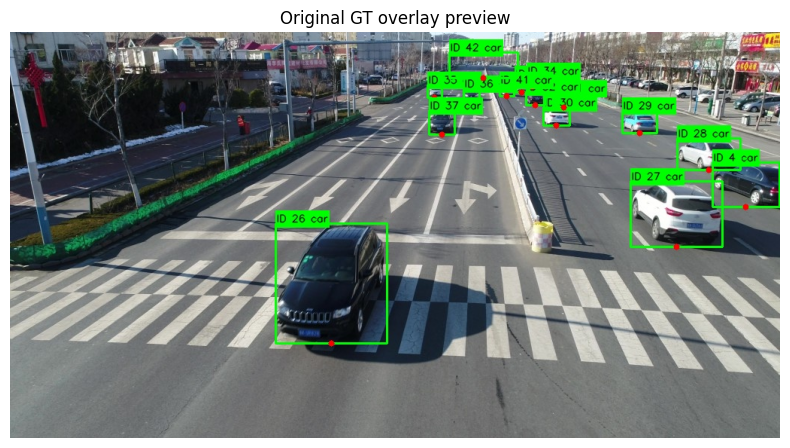

In [8]:
#@title 8. Render original-frame annotation overlays

if 'MAX_RENDER_FRAMES' not in globals():
    MAX_RENDER_FRAMES = 30

annotated_dir = NB03A_DIR / 'original_gt_overlays'
if annotated_dir.exists():
    shutil.rmtree(annotated_dir)
annotated_dir.mkdir(parents=True, exist_ok=True)

frame_lookup = {p.name: p for p in sample_images}
render_frame_ids = sorted(tracks['frame_id'].unique().tolist())[:MAX_RENDER_FRAMES]

CLASS_COLORS = {
    'car': (0, 255, 0),
    'truck': (255, 165, 0),
    'bus': (0, 128, 255),
    'vehicle': (255, 255, 0),
}

def draw_label(img, text, x, y, color):
    font = cv2.FONT_HERSHEY_SIMPLEX
    scale = 0.45
    thickness = 1
    (tw, th), baseline = cv2.getTextSize(text, font, scale, thickness)
    x = int(max(0, min(x, img.shape[1] - 1)))
    y = int(max(th + 2, min(y, img.shape[0] - 1)))
    cv2.rectangle(img, (x, y - th - baseline - 2), (x + tw + 2, y + baseline), color, -1)
    cv2.putText(img, text, (x + 1, y - 2), font, scale, (0, 0, 0), thickness, cv2.LINE_AA)

out_paths_original = []
for frame_id in render_frame_ids:
    fdf = tracks[tracks['frame_id'] == frame_id]
    sample_name = str(fdf['frame'].iloc[0])
    img_path = frame_lookup.get(sample_name)
    if img_path is None:
        continue
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    for _, r in fdf.iterrows():
        color = CLASS_COLORS.get(str(r['class_name']), (255, 255, 0))
        x1, y1, x2, y2 = int(r['x1']), int(r['y1']), int(r['x2']), int(r['y2'])
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        label = 'ID ' + str(int(r['track_id'])) + ' ' + str(r['class_name'])
        draw_label(img, label, x1, y1, color)
        cx = int(r['bbox_cx'])
        gy = int(r['bbox_ground_y'])
        cv2.circle(img, (cx, gy), 4, (0, 0, 255), -1)
    out_path = annotated_dir / ('gt_overlay_frame_' + str(int(frame_id)).zfill(6) + '.jpg')
    cv2.imwrite(str(out_path), img)
    out_paths_original.append(out_path)

print('Saved original overlays:', len(out_paths_original))
print('Directory:', annotated_dir)

if len(out_paths_original) > 0:
    preview = cv2.cvtColor(cv2.imread(str(out_paths_original[0])), cv2.COLOR_BGR2RGB)
    h, w = preview.shape[:2]
    plt.figure(figsize=(10, 10 * h / w))
    plt.imshow(preview)
    plt.axis('off')
    plt.title('Original GT overlay preview')
    plt.show()


Saved BEV overlays: 30
Directory: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_03a_gt_annotations_bev_tracks/bev_gt_overlays


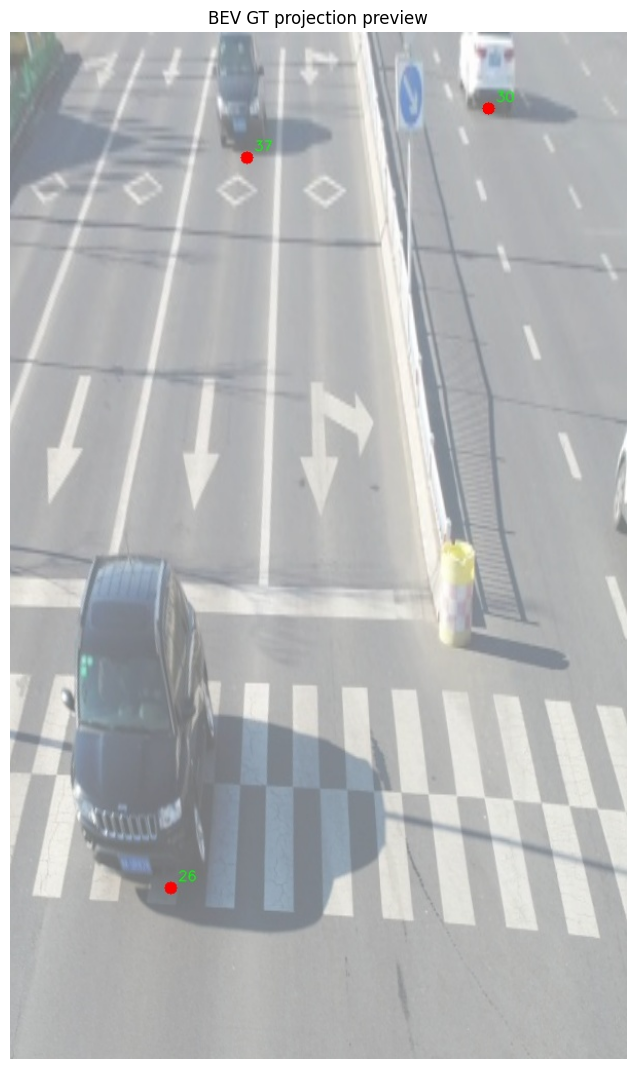

In [9]:
#@title 9. Render BEV projection overlays

bev_overlay_dir = NB03A_DIR / 'bev_gt_overlays'
if bev_overlay_dir.exists():
    shutil.rmtree(bev_overlay_dir)
bev_overlay_dir.mkdir(parents=True, exist_ok=True)

# Use warped reference frame as background for all BEV overlays.
ref_img = cv2.imread(str(sample_images[0]))
if ref_img is None:
    raise RuntimeError('Could not load reference sample image: ' + str(sample_images[0]))
bev_bg = cv2.warpPerspective(ref_img, H_image_to_bev, (BEV_WIDTH, BEV_HEIGHT))
cv2.imwrite(str(NB03A_DIR / 'bev_reference_from_homography.jpg'), bev_bg)

# Precompute short track histories.
tracks_sorted = tracks.sort_values(['track_id', 'frame_id']).copy()
out_paths_bev = []

for frame_id in render_frame_ids:
    canvas = bev_bg.copy()
    # Fade background to make points easier to see.
    canvas = cv2.addWeighted(canvas, 0.55, np.full_like(canvas, 255), 0.45, 0)

    # Draw trajectory history until current frame.
    hist = tracks_sorted[tracks_sorted['frame_id'] <= frame_id]
    for track_id, g in hist.groupby('track_id'):
        g = g.sort_values('frame_id')
        pts = g[['bev_x_px', 'bev_y_px']].to_numpy(dtype=float)
        pts = pts[np.isfinite(pts).all(axis=1)]
        if len(pts) >= 2:
            for i in range(1, len(pts)):
                p0 = tuple(np.round(pts[i - 1]).astype(int))
                p1 = tuple(np.round(pts[i]).astype(int))
                cv2.line(canvas, p0, p1, (255, 0, 0), 2)

    # Draw current detections.
    fdf = tracks_sorted[tracks_sorted['frame_id'] == frame_id]
    for _, r in fdf.iterrows():
        bx = int(round(r['bev_x_px']))
        by = int(round(r['bev_y_px']))
        color = CLASS_COLORS.get(str(r['class_name']), (255, 255, 0))
        cv2.circle(canvas, (bx, by), 6, (0, 0, 255), -1)
        cv2.putText(canvas, str(int(r['track_id'])), (bx + 7, by - 7), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA)

    out_path = bev_overlay_dir / ('bev_gt_frame_' + str(int(frame_id)).zfill(6) + '.jpg')
    cv2.imwrite(str(out_path), canvas)
    out_paths_bev.append(out_path)

print('Saved BEV overlays:', len(out_paths_bev))
print('Directory:', bev_overlay_dir)

if len(out_paths_bev) > 0:
    preview = cv2.cvtColor(cv2.imread(str(out_paths_bev[0])), cv2.COLOR_BGR2RGB)
    h, w = preview.shape[:2]
    plt.figure(figsize=(8, 8 * h / w))
    plt.imshow(preview)
    plt.axis('off')
    plt.title('BEV GT projection preview')
    plt.show()


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1797, 720) to (1808, 720) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved side-by-side frames: 30
Saved video: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_03a_gt_annotations_bev_tracks/gt_original_vs_bev_validation.mp4


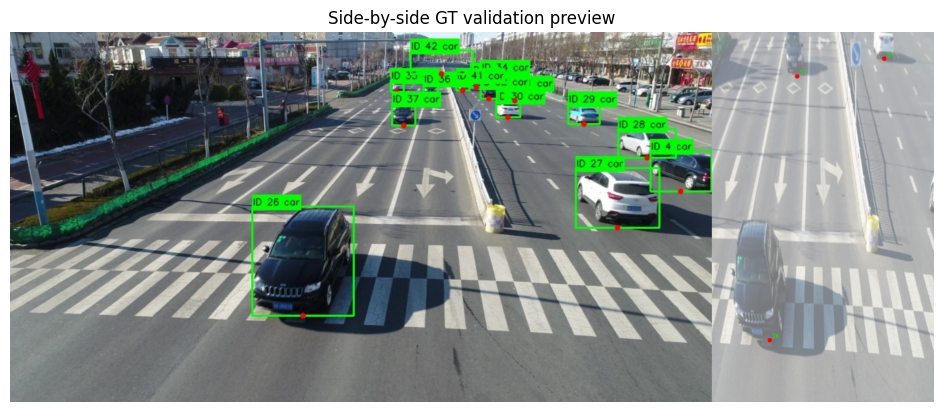

In [10]:
#@title 10. Create side-by-side validation video

if 'VIDEO_FPS' not in globals():
    VIDEO_FPS = 8

side_by_side_dir = NB03A_DIR / 'side_by_side_frames'
if side_by_side_dir.exists():
    shutil.rmtree(side_by_side_dir)
side_by_side_dir.mkdir(parents=True, exist_ok=True)

side_paths = []
for orig_path, bev_path in zip(out_paths_original, out_paths_bev):
    orig = cv2.imread(str(orig_path))
    bev = cv2.imread(str(bev_path))
    if orig is None or bev is None:
        continue

    target_h = 720
    orig_w = int(orig.shape[1] * target_h / orig.shape[0])
    bev_w = int(bev.shape[1] * target_h / bev.shape[0])
    orig_resized = cv2.resize(orig, (orig_w, target_h))
    bev_resized = cv2.resize(bev, (bev_w, target_h))

    combined = np.concatenate([orig_resized, bev_resized], axis=1)
    out_path = side_by_side_dir / ('side_by_side_' + orig_path.stem.split('_')[-1] + '.jpg')
    cv2.imwrite(str(out_path), combined)
    side_paths.append(out_path)

video_path = NB03A_DIR / 'gt_original_vs_bev_validation.mp4'
if len(side_paths) > 0:
    imgs_rgb = [cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB) for p in side_paths]
    imageio.mimsave(str(video_path), imgs_rgb, fps=VIDEO_FPS)

print('Saved side-by-side frames:', len(side_paths))
print('Saved video:', video_path)

if len(side_paths) > 0:
    preview = cv2.cvtColor(cv2.imread(str(side_paths[0])), cv2.COLOR_BGR2RGB)
    h, w = preview.shape[:2]
    plt.figure(figsize=(12, 12 * h / w))
    plt.imshow(preview)
    plt.axis('off')
    plt.title('Side-by-side GT validation preview')
    plt.show()


In [11]:
#@title 11. Track summary and outputs for downstream notebooks

summary = tracks.groupby('track_id').agg(
    first_frame=('frame_id', 'min'),
    last_frame=('frame_id', 'max'),
    num_frames=('frame_id', 'count'),
    class_name=('class_name', lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0]),
    mean_bev_x_px=('bev_x_px', 'mean'),
    mean_bev_y_px=('bev_y_px', 'mean'),
).reset_index()
summary['duration_frames'] = summary['last_frame'] - summary['first_frame'] + 1

summary_path = NB03A_DIR / 'gt_track_summary.csv'
summary.to_csv(summary_path, index=False)

# Also write a compatibility copy that later notebooks can load.
compat_path = NB03A_DIR / 'vehicle_tracks_bev.csv'
tracks.to_csv(compat_path, index=False)

print('Saved track summary:', summary_path)
print('Saved compatibility BEV tracks:', compat_path)
print('Main outputs:')
print(' ', bev_tracks_path)
print(' ', compat_path)
print(' ', video_path)

display(summary.sort_values('num_frames', ascending=False).head(20))


Saved track summary: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_03a_gt_annotations_bev_tracks/gt_track_summary.csv
Saved compatibility BEV tracks: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_03a_gt_annotations_bev_tracks/vehicle_tracks_bev.csv
Main outputs:
  /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_03a_gt_annotations_bev_tracks/vehicle_tracks_bev_gt.csv
  /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_03a_gt_annotations_bev_tracks/vehicle_tracks_bev.csv
  /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_03a_gt_annotations_bev_tracks/gt_original_vs_bev_validation.mp4


,track_id,first_frame,last_frame,num_frames,class_name,mean_bev_x_px,mean_bev_y_px,duration_frames
0,4,0,39,40,car,487.298279,53.858742,40
8,28,0,39,40,car,506.860046,16.767305,40
21,41,0,39,40,car,294.377380,-166.983566,40
13,33,0,39,40,car,308.046509,-185.738434,40
12,32,0,39,40,car,341.998871,-147.740402,40
10,30,0,39,40,car,358.526886,-77.635521,40
9,29,0,39,40,car,470.101746,-56.582897,40
11,31,0,39,40,car,380.105591,-139.811615,40
7,27,0,39,40,car,439.691223,121.955368,40
14,34,0,33,34,car,335.969086,-204.964722,34
